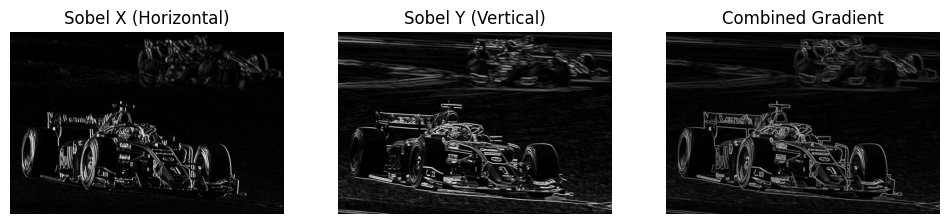

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read image
src = cv2.imread(r"C:\Users\user\OneDrive\Desktop\f1 car image -2.webp")

if src is None:
    print("Image not found!")
else:
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(src, (3, 3), 0)

    # Convert to grayscale
    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)

    # Apply Sobel operator
    grad_x = cv2.Sobel(gray, cv2.CV_16S, 1, 0, ksize=3, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)  # Horizontal edges
    grad_y = cv2.Sobel(gray, cv2.CV_16S, 0, 1, ksize=3, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)  # Vertical edges

    # Convert to absolute values
    abs_grad_x = cv2.convertScaleAbs(grad_x)
    abs_grad_y = cv2.convertScaleAbs(grad_y)

    # Combine gradients
    grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

    # Show results
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(abs_grad_x, cmap='gray'); plt.title("Sobel X (Horizontal)"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(abs_grad_y, cmap='gray'); plt.title("Sobel Y (Vertical)"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(grad, cmap='gray'); plt.title("Combined Gradient"); plt.axis("off")
    plt.show()
